**Emotion Classification with RNN, LSTMs & GRU**

#**1. Import Libraries**

import TensorFlowKeras, HuggingFace Datasets, and Evalution tool


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# dataset load karwane me help karegi

from datasets import load_dataset

#**2. Load Dataset**

Load the dair-ai/emotion dataset from Hugging Face.https://huggingface.co/datasets/dair-ai/emotion

In [3]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']


test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
label_names = emotion_dataset['train'].features['label'].names

In [5]:
df_train = pd.DataFrame(
    {
        'text' : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text' : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [6]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [7]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [8]:
df_train.isnull().sum()

,0
text,0
label,0


#**3. Exploratory Data Analysis (EDA)**

Visualize class distribution across the 6 emotion labels.

In [9]:
print(df_train['label'].value_counts().index)   # order wise descending

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')


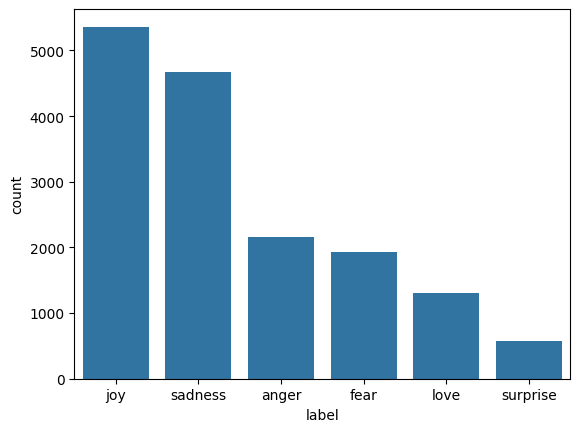

In [10]:
sns.countplot(x = 'label', data = df_train, order = df_train['label'].value_counts().index )
plt.show()

#**4. Data Preprocessing - Using NLP**

Tokenize text, pad sequences to max length 50, and convert labels to Numpy arrays.

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000    # agar boht saare words hai toh limit jyada ho jayegi isliye hum ek limit set kar denge ki bass itne words dekho (10000)

tokenizer = Tokenizer(num_words = max_words, oov_token = '<unk>')   # oov_token = '<unk>' --> aisa word jo training ke time kabhi appear hi nhi hua toh hum usko 'unk' se mark kar denge
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])   #-> number me convert kar dega  (jyada baar aa rha -> lower number, kam baar aa rha -> greater number (importance high))
test_sequence = tokenizer.texts_to_sequences(df_test['text'])


padded_train_sequence = pad_sequences(train_sequence, maxlen = 50, padding = 'post', truncating = 'post')  # input size same karega
padded_test_sequence = pad_sequences(test_sequence, maxlen = 50, padding = 'post', truncating = 'post')


train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Senetence Length: {padded_train_sequence.shape[1]}")
print(f"Number of Classes: {num_classes}")


Vocabulary Size: 15213
Max Senetence Length: 50
Number of Classes: 6


#**5. Shared Training Utilities**

Compute balanced class weights to handle dataset skew and setup early stopping.

In [26]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
     class_weight = 'balanced',
     classes      =  np.unique(train_labels),
     y            = train_labels

)

class_weight_dict = dict(enumerate(class_weights))     # harr class ko weight assign karna taaki model biased naa ho

In [28]:
# early stopping ->    after some epochs model ka loss kam hona band ho gya iska mtlb ab model overfit ho rha hai isliye training stop karna

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)




#**6. Phase 1 - Plain Foundation Models**


Train plain (non-bidirectional) simple RNN, standard LSTM, and Standard GRU models.





**6.1 Model 1 - Simple RNN**

plain unrolled Recurrent Neural Network

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    SimpleRNN(units=128, return_sequences = True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')    #Output Layer
])


rnn_model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

rnn_model.fit(padded_train_sequence,
              train_labels,
              epochs = 20,
              validation_data = (padded_test_sequence, test_labels),
              callbacks = [early_stopping],
              class_weight = class_weight_dict,
              batch_size =32
)


rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"Simple RNN Test Loss : {rnn_loss}")
print(f"Simple RNN Test Accuracy : {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - accuracy: 0.1517 - loss: 2.0462 - val_accuracy: 0.1765 - val_loss: 1.7659
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.1426 - loss: 1.8980 - val_accuracy: 0.2130 - val_loss: 1.7790
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - accuracy: 0.1295 - loss: 1.8273 - val_accuracy: 0.1430 - val_loss: 1.7910
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1765 - loss: 1.7659
Simple RNN Test Loss : 1.765871286392212
Simple RNN Test Accuracy : 0.17649999260902405


**6.2 Model - Standard LSTM**

plain stacked Long Short-Term Memory network.

In [45]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    LSTM(units=128, return_sequences = True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')    #Output Layer
])


lstm_model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

lstm_model.fit(padded_train_sequence,
              train_labels,
              epochs = 20,
              validation_data = (padded_test_sequence, test_labels),
              class_weight = class_weight_dict,
              batch_size =32,
               callbacks = [early_stopping]
)


lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"Simple LSTM Test Loss : {lstm_loss}")
print(f"Simple LSTM Test Accuracy : {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 146ms/step - accuracy: 0.1561 - loss: 1.7948 - val_accuracy: 0.0330 - val_loss: 1.8136
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 141ms/step - accuracy: 0.1383 - loss: 1.7930 - val_accuracy: 0.0790 - val_loss: 1.7683
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - accuracy: 0.1413 - loss: 1.7921 - val_accuracy: 0.2810 - val_loss: 1.7686
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 140ms/step - accuracy: 0.1839 - loss: 1.7476 - val_accuracy: 0.2730 - val_loss: 1.7127
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 152ms/step - accuracy: 0.2988 - loss: 1.5218 - val_accuracy: 0.3745 - val_loss: 1.4987
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 141ms/step - accuracy: 0.5323 - loss: 0.9938 - val_accuracy: 0.5460 - val_loss: 1.0633
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 146ms/step - accuracy: 0.7613 - loss: 0.5975 - val_accuracy: 0.8315 - val_loss: 0.5300
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - accuracy: 0.8596 - loss: 0

**6.3 Model 3 - Standard GRU**

plain stacked Gated Recurrent Unit network


In [46]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    GRU(units=128, return_sequences = True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')    #Output Layer
])


gru_model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

gru_model.fit(padded_train_sequence,
              train_labels,
              epochs = 20,
              validation_data = (padded_test_sequence, test_labels),
              callbacks = [early_stopping],
              class_weight = class_weight_dict,
              batch_size =32
              )


gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Test Loss : {gru_loss}")
print(f"GRU Test Accuracy : {gru_accuracy}")

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 123ms/step - accuracy: 0.1446 - loss: 1.7967 - val_accuracy: 0.0335 - val_loss: 1.7929
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 64s 128ms/step - accuracy: 0.1450 - loss: 1.7963 - val_accuracy: 0.3485 - val_loss: 1.7811
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - accuracy: 0.1619 - loss: 1.7940 - val_accuracy: 0.1125 - val_loss: 1.8081
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0335 - loss: 1.7929
GRU Test Loss : 1.7929470539093018
GRU Test Accuracy : 0.03350000083446503


**6.4 Phase 1 ranking & Selecton**

Rank foundation models to pik the best base cell for phase 2.

In [50]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss' : [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy' : [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending = False)

result_df


,Model,Test Loss,Test Accuracy
1,LSTM,0.316699,0.9030
0,RNN,1.765871,0.1765
2,GRU,1.792947,0.0335


#**7. Phase 2 -- Advanced Bidirectional GRU**

Enhance GRU with Bidirectional layers , 300D embedings, and 0.5 dropout regularization

**7.1 Model 4 -- Advanced Stacked Bidirectional GRU**

 bidirectional = (left -> right) + (right -> left)

In [52]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
     Embedding(input_dim = max_words, output_dim = 300, input_length = 50),
     Bidirectional(GRU(units=128, return_sequences = True)),
     Dropout(0.5),
     Bidirectional(GRU(units=64)),
     Dropout(0.5),
     Dense(units=num_classes, activation='softmax')

])

BiGRU.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train & Evaluation & Bias Analysis**

In [53]:
BiGRU.fit(padded_train_sequence,
              train_labels,
              epochs = 20,
              validation_data = (padded_test_sequence, test_labels),
              callbacks = [early_stopping],
              class_weight = class_weight_dict,
              batch_size =32
)

BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"Simple RNN Test Loss : {BiGRU_loss}")
print(f"Simple RNN Test Accuracy : {BiGRU_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 178s 341ms/step - accuracy: 0.5784 - loss: 1.0698 - val_accuracy: 0.8900 - val_loss: 0.3629
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 200s 337ms/step - accuracy: 0.9132 - loss: 0.2661 - val_accuracy: 0.9095 - val_loss: 0.2638
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 203s 339ms/step - accuracy: 0.9401 - loss: 0.1569 - val_accuracy: 0.9195 - val_loss: 0.2027
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 210s 355ms/step - accuracy: 0.9572 - loss: 0.1143 - val_accuracy: 0.9240 - val_loss: 0.2224
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 195s 341ms/step - accuracy: 0.9690 - loss: 0.0885 - val_accuracy: 0.9225 - val_loss: 0.2704
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 168s 336ms/step - accuracy: 0.9766 - loss: 0.0653 - val_accuracy: 0.9225 - val_loss: 0.2836
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9195 - loss: 0.2027
Simple RNN Test Loss : 0.20274171233177185
Simple RNN Test Accuracy : 0.9194999933242798


#**8. Overall Evaluation & Bias Analysis**

Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

**8.1 Final Model Confusion Matrices (Raw counts & Normalized %)**

63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step


<Axes: >

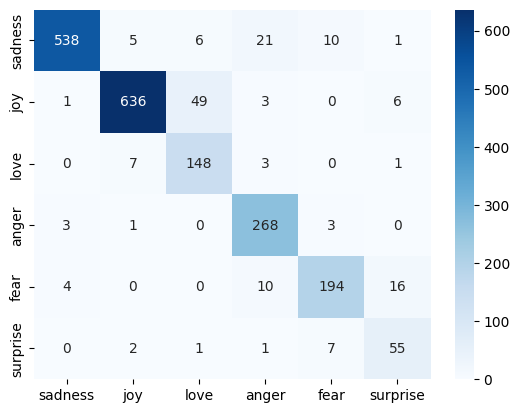

In [57]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot = True, fmt='d', cmap='Blues',  xticklabels = label_names, yticklabels = label_names)



#**9. Final Predictions**

Test the winning model on unseen sample sentences.

In [59]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alley ways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')


sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f"Text : {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Text : I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text : I feel so alone and hopeless today.
Predicted Emotion: sadness
Text : I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text : I feel terrified when walking down dark alley ways alone.
Predicted Emotion: fear
Text : I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


#**10. Save Model & Tokenizer**

Export trained mmodel and tokenizer artifacts for API deployment

In [63]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir,exist_ok=True)    # yeh Folder hai jiske andar saari exported files aane wali hai

# save our BiGRU Model
BiGRU.save(os.path.join(model_dir,'BiGRU_Model.keras' ))

# save the tokenizer model

with open(os.path.join(model_dir,'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)
